Step 2: Load and Inspect the Excel File

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Replace with your actual file path
file_path = 'kse-30-basic.xlsx'  # e.g., 'C:/Users/YourName/Downloads/kse30_data.xlsx'

# Read the Excel file (assumes data in first sheet; adjust sheet_name if needed)
df = pd.read_excel(file_path, engine='openpyxl')  # or xlrd if older xls

# Standardize column names (case insensitive, strip spaces)
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')

# Basic inspection
print("Shape:", df.shape)
print(df.head(10))
print(df.info())
print("Unique companies:", df['company'].nunique())  # adjust column name if different
print("Date range:", df['date'].min(), "to", df['date'].max())

# Convert date from Excel serial number to datetime
df['date'] = pd.to_datetime(df['date'], unit='D', origin='1899-12-30')

# Drop rows with missing critical columns
df = df.dropna(subset=['date', 'company', 'price', 'idx_wt_%', 'volume'])  # adjust column names if different

# Sort by date and company
df_cleaned = df.sort_values(['date', 'company']).reset_index(drop=True)

print("Cleaned data ready. Rows:", len(df_cleaned))

Shape: (42330, 6)
    date   symbol                         company   price  idx_wt_%    volume
0  45649  AIRLINK  Air Link Communication Limited  215.53  0.869499  10266206
1  45650  AIRLINK  Air Link Communication Limited  210.38  0.861528   8765161
2  45652  AIRLINK  Air Link Communication Limited  213.91  0.894374   3834991
3  45653  AIRLINK  Air Link Communication Limited  215.74  0.895306   3848039
4  45656  AIRLINK  Air Link Communication Limited  217.38  0.870778   1497575
5  45657  AIRLINK  Air Link Communication Limited  220.00  0.864055   5090891
6  45658  AIRLINK  Air Link Communication Limited  222.43  0.857427   4690463
7  45659  AIRLINK  Air Link Communication Limited  222.89  0.857521   2703007
8  45660  AIRLINK  Air Link Communication Limited  217.98  0.835734   3144956
9  45663  AIRLINK  Air Link Communication Limited  210.97  0.837705   2301398
<class 'pandas.DataFrame'>
RangeIndex: 42330 entries, 0 to 42329
Data columns (total 6 columns):
 #   Column    Non-Null Cou

In [20]:
df = df_cleaned.copy()  # Work on a copy to avoid SettingWithCopyWarning

Step 3: Aggregate to Index-Level Daily Data
Compute weighted index return and total volume.

In [21]:
df.head()

,date,symbol,company,price,idx_wt_%,volume
0,2020-01-01,BAHL,Bank Al-Habib Ltd.,77.33,4.29,257500
1,2020-01-01,BAFL,Bank Alfalah Ltd.,46.74,2.55,1128000
2,2020-01-01,BOP,Bank Of Punjab.,11.73,1.01,7507000
3,2020-01-01,DGKC,D. G. Khan Cement Co. Ltd.,75.23,1.27,1501000
4,2020-01-01,ENGRO,Engro Corporation Limited.,354.28,8.63,231900


In [22]:
# Ensure idx_wt_% is in decimal form (if it's %, divide by 100)
if df['idx_wt_%'].max() > 1:
    df['idx_wt_%'] = df['idx_wt_%'] / 100

# Group by date to create index-level series
index_df = df.groupby('date').apply(
    lambda x: pd.Series({
        'index_return': np.sum(x['price'].pct_change().fillna(0) * x['idx_wt_%']),  # daily simple weighted return
        'log_return': np.sum(np.log(x['price'] / x['price'].shift(1).fillna(x['price'])) * x['idx_wt_%']),
        'total_volume': x['volume'].sum(),
        'avg_weight_change': x['idx_wt_%'].diff().abs().mean(),  # rough rebalancing signal
        'num_companies': x['company'].nunique()
    })
).reset_index()

# Fill any small gaps (forward fill for returns/volume)
index_df = index_df.set_index('date').asfreq('B').ffill().reset_index()  # business days

print(index_df.head())
index_df.to_csv('kse30_index_level.csv', index=False)  # save for reuse

        date  index_return  log_return  total_volume  avg_weight_change  \
0 2020-01-01      4.192384    0.336747    55169900.0           0.028652   
1 2020-01-02      4.147105    0.336081   151334700.0           0.028714   
2 2020-01-03      4.197470    0.337646   130968430.0           0.028572   
3 2020-01-06      4.272946    0.346243    96604890.0           0.028779   
4 2020-01-07      4.370498    0.349776    70796630.0           0.028707   

   num_companies  
0           30.0  
1           30.0  
2           30.0  
3           30.0  
4           30.0  


Step 4: Create Proxy for Fund Flows (Monthly)
Since you don't have NAV/AUM, use abnormal trading volume + return pressure as proxy (common in emerging market studies for sentiment/flows).

         date  log_return  abnormal_volume  flow_proxy
60 2025-01-31   13.219499         0.882259   11.663025
61 2025-02-28   11.223779         0.610428    6.851313
62 2025-03-31   10.339250         0.870089    8.996066
63 2025-04-30   10.515370         1.105917   11.629126
64 2025-05-31   10.191796         0.983030   10.018842
65 2025-06-30    8.351623         0.878839    7.339733
66 2025-07-31    9.295246         1.029831    9.572528
67 2025-08-31    8.049525         1.225045    9.861032
68 2025-09-30    8.230679         1.424589   11.725334
69 2025-10-31    0.408713         0.171572    0.070124


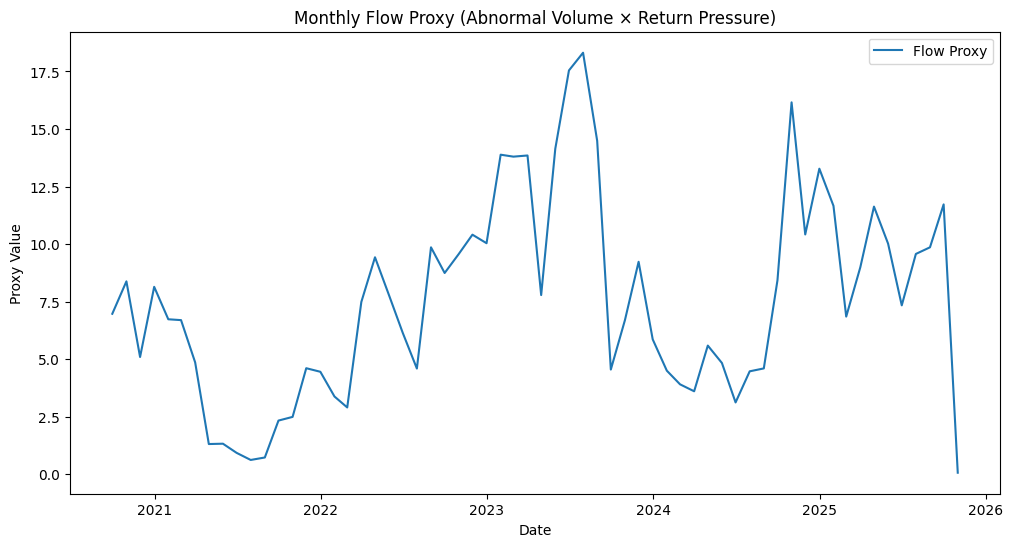

In [23]:
# Resample to monthly (end of month)
monthly_df = index_df.set_index('date').resample('ME').agg({
    'log_return': 'sum',                # monthly log return
    'total_volume': 'sum',              # total monthly volume
    'avg_weight_change': 'mean'
}).reset_index()

# Calculate rolling average volume (e.g., 3-month rolling mean)
monthly_df['avg_volume_3m'] = monthly_df['total_volume'].rolling(window=3).mean()

# Abnormal volume (proxy for unusual activity → potential inflows/outflows)
monthly_df['abnormal_volume'] = monthly_df['total_volume'] / monthly_df['avg_volume_3m']

# Flow proxy: abnormal volume * signed return momentum (positive = inflow pressure)
monthly_df['flow_proxy'] = monthly_df['abnormal_volume'] * np.sign(monthly_df['log_return']) * abs(monthly_df['log_return'])

# Lagged features for prediction
for lag in [1, 3, 6]:
    monthly_df[f'log_return_lag{lag}'] = monthly_df['log_return'].shift(lag)
    monthly_df[f'abnormal_volume_lag{lag}'] = monthly_df['abnormal_volume'].shift(lag)

monthly_df = monthly_df.dropna()  # drop initial NaNs

print(monthly_df[['date', 'log_return', 'abnormal_volume', 'flow_proxy']].tail(10))

# Quick plot
plt.figure(figsize=(12, 6))
plt.plot(monthly_df['date'], monthly_df['flow_proxy'], label='Flow Proxy')
plt.title('Monthly Flow Proxy (Abnormal Volume × Return Pressure)')
plt.xlabel('Date')
plt.ylabel('Proxy Value')
plt.legend()
plt.show()

Note: This is a rough proxy. For better accuracy, download monthly NAV/AUM from MUFAP.com.pk (e.g., for equity funds tracking KSE-30) and compute true flows as:
Flow_t = (AUM_t - AUM_{t-1} × (1 + return_t)) / AUM_{t-1}

Step 6: Machine Learning – Predict Next Month's Flow Proxy

RF - MSE: 21.089027999194002
RF - R²: -0.5181049413685479
XGB - MSE: 28.41713360202108
XGB - R²: -1.0456225361551597
Feature Importances:
 avg_weight_change       0.814081
abnormal_volume_lag1    0.074337
log_return_lag6         0.043758
log_return_lag1         0.033857
log_return_lag3         0.026872
abnormal_volume_lag3    0.007095
dtype: float32


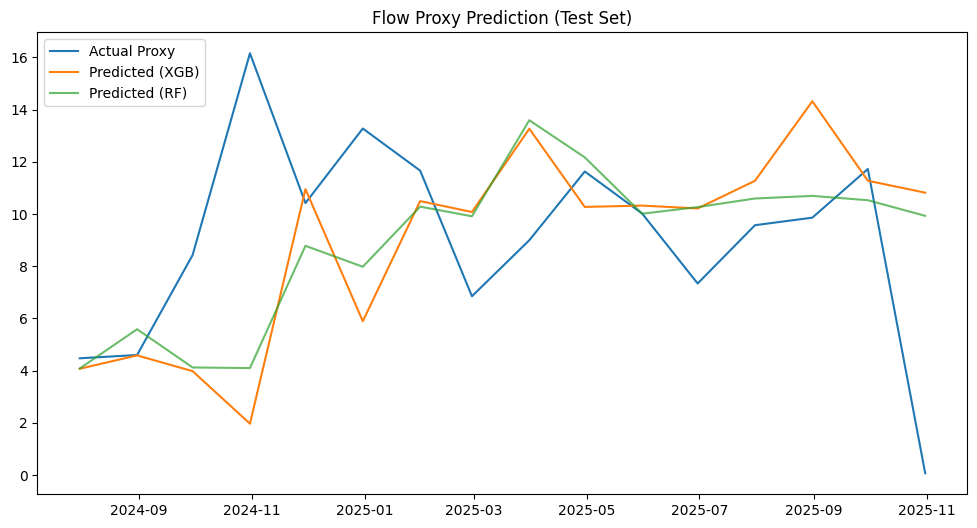

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb

# Features (add more if you have macro data later)
features = ['log_return_lag1', 'log_return_lag3', 'log_return_lag6',
            'abnormal_volume_lag1', 'abnormal_volume_lag3',
            'avg_weight_change']

X = monthly_df[features]
y = monthly_df['flow_proxy'].shift(-1)  # predict NEXT month's proxy

# Drop last row (no future target)
X = X.iloc[:-1]
y = y.iloc[:-1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=False)  # time-series split

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
preds_rf = rf.predict(X_test)

print("RF - MSE:", mean_squared_error(y_test, preds_rf))
print("RF - R²:", r2_score(y_test, preds_rf))

# XGBoost (often better for small data)
model_xgb = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model_xgb.fit(X_train, y_train)
preds_xgb = model_xgb.predict(X_test)

print("XGB - MSE:", mean_squared_error(y_test, preds_xgb))
print("XGB - R²:", r2_score(y_test, preds_xgb))

# Feature importance
importances = pd.Series(model_xgb.feature_importances_, index=features).sort_values(ascending=False)
print("Feature Importances:\n", importances)

# Plot predictions
plt.figure(figsize=(12, 6))
plt.plot(monthly_df['date'].iloc[-len(y_test):], y_test, label='Actual Proxy')
plt.plot(monthly_df['date'].iloc[-len(y_test):], preds_xgb, label='Predicted (XGB)')
plt.plot(monthly_df['date'].iloc[-len(y_test):], preds_rf, label='Predicted (RF)', alpha=0.7)
plt.title('Flow Proxy Prediction (Test Set)')
plt.legend()
plt.show()


Step 7: Rough Optimal Weight Allocation Suggestion
Use predicted flow to tilt weights (simple rule-based for MVP).

In [26]:
# Assume last prediction is for next month
last_pred = preds_xgb[-1]

# Example: if predicted inflow > threshold, overweight high-volume stocks
threshold = monthly_df['flow_proxy'].mean()

if last_pred > threshold:
    print("Predicted inflow → Suggest overweight high-momentum/volume stocks")
    # Example: top 10 by recent volume
    recent = df[df['date'] == df['date'].max()].sort_values('volume', ascending=False).head(10)
    print("Suggested overweight companies:\n", recent[['company', 'volume', 'idx_wt_%']])
else:
    print("Predicted outflow/flat → Suggest defensive or equal-weight")

# For real optimization → install pyportfolioopt and use predicted returns/vol

Predicted inflow → Suggest overweight high-momentum/volume stocks
Suggested overweight companies:
                                    company     volume  idx_wt_%
42302                     Bank Of Punjab.   191997025  0.011487
42319                   Pak Elektron Ltd.   132355135  0.008405
42311          Hub Power Company Limited.    13042153  0.059498
42317          National Bank Of Pakistan.    12492878  0.029045
42306                Fauji Cement Co Ltd.     8736512  0.014573
42322              Pakistan Refinery Ltd.     8208613  0.002275
42303          D. G. Khan Cement Co. Ltd.     7089151  0.015881
42323          Pakistan State Oil Co Ltd.     6837555  0.030783
42321         Pakistan Petroleum Limited.     6827405  0.038213
42318  Oil & Gas Development Company Ltd.     6107600  0.049796


Step 5: Basic Market Efficiency Checks
Simple Hurst exponent (rescaled range) and variance ratio sketch.

In [27]:
from scipy import stats

# Hurst Exponent (simple R/S on log returns)
def hurst_exponent(ts, min_lag=4, max_lag=None):
    ts = np.array(ts)
    N = len(ts)
    if max_lag is None:
        max_lag = N // 4
    lags, rs = [], []
    for lag in range(min_lag, max_lag + 1):
        rs_sub = []
        for k in range(0, N - lag, lag):
            sub = ts[k:k+lag]
            if len(sub) < 2: continue
            mean = np.mean(sub)
            y = sub - mean
            cum_dev = np.cumsum(y)
            r = np.max(cum_dev) - np.min(cum_dev)
            s = np.std(y)
            if s > 0:
                rs_sub.append(r / s)
        if rs_sub:
            lags.append(lag)
            rs.append(np.mean(rs_sub))
    if len(lags) < 3:
        return np.nan
    log_lags = np.log(lags)
    log_rs = np.log(rs)
    slope, _, _, _, _ = stats.linregress(log_lags, log_rs)
    return slope

hurst = hurst_exponent(monthly_df['log_return'].values)
print(f"Hurst Exponent: {hurst:.3f}")  # ~0.5 = random walk; >0.5 persistent

# Simple Variance Ratio (q=3 months)
q = 3
var1 = monthly_df['log_return'].var()
var_q = monthly_df['log_return'].rolling(q).sum().var()
vr = var_q / (q * var1)
print(f"Variance Ratio (q={q}): {vr:.3f}")  # ≈1 = efficient

Hurst Exponent: 1.052
Variance Ratio (q=3): 2.724
